In [1]:
%load_ext autoreload
%autoreload 2
import sys
sys.setrecursionlimit(10000)

import numpy as np
from matplotlib import pyplot as plt

from biotite.structure.io.pdbx.encoding import DeltaEncoding
from bio_datasets.structure.parsing import load_structure
from bio_datasets.structure.protein.constants import BACKBONE_BOND_LENGTHS, BACKBONE_BOND_ANGLES
from bio_datasets.structure.protein.internal_coordinates import get_backbone_internals, load_backbone_coord_array
from bio_datasets.structure.protein.compress.encoding import BinEncoding, HistogramEncoding, SparseHistogramEncoding

/Users/alex/projects/opensource/fast-datasets/src/datasets/utils/experimental.py:37: UserWarning: 'register_feature' is experimental and might be subject to breaking changes in the future.
  warnings.warn(


In [2]:
PDB_FILE = "../tests/AF-Q9R172-F1-model_v4.pdb"

In [3]:
def load_coords(pdb_file: str, chain: str = "A"):
    """Load cartesian coordinates and internal coordinates for a protein backbone from a PDB file."""
    struct = load_structure(pdb_file)
    struct = struct[struct.chain_id == chain]
    xyz_bb = load_backbone_coord_array(struct)
    print(xyz_bb.shape)
    internals = get_backbone_internals(xyz_bb)
    return xyz_bb, internals

xyz_bb, internals = load_coords(PDB_FILE)
bond_lengths, bond_angles, dihedrals = internals

(2319, 3, 3)


In [10]:
2319*3

6957

In [11]:
bond_angles.min(), bond_angles.max()

(0.5817363, 1.3259978)

Text(0.5, 1.0, 'Difference between actual bond angles and idealised values')

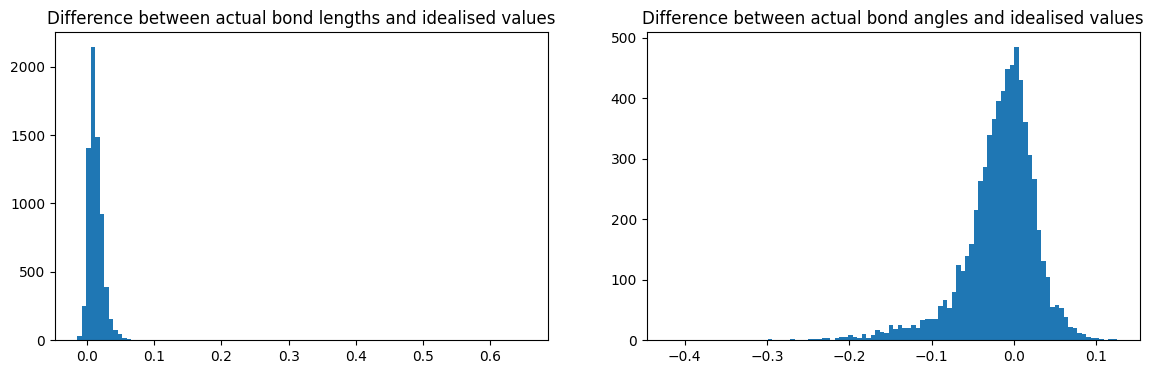

In [4]:
fig = plt.figure(figsize=(14, 4))
ax = plt.subplot(1, 2, 1)

length_diffs = bond_lengths - BACKBONE_BOND_LENGTHS
angle_diffs = bond_angles - BACKBONE_BOND_ANGLES

ax.hist(length_diffs.reshape(-1), bins=100)
ax.set_title("Difference between actual bond lengths and idealised values", fontsize=12)


ax = plt.subplot(1, 2, 2)
ax.hist(angle_diffs[1:].reshape(-1), bins=100)
ax.set_title("Difference between actual bond angles and idealised values", fontsize=12)

Text(0.5, 1.0, 'Bond angle 2')

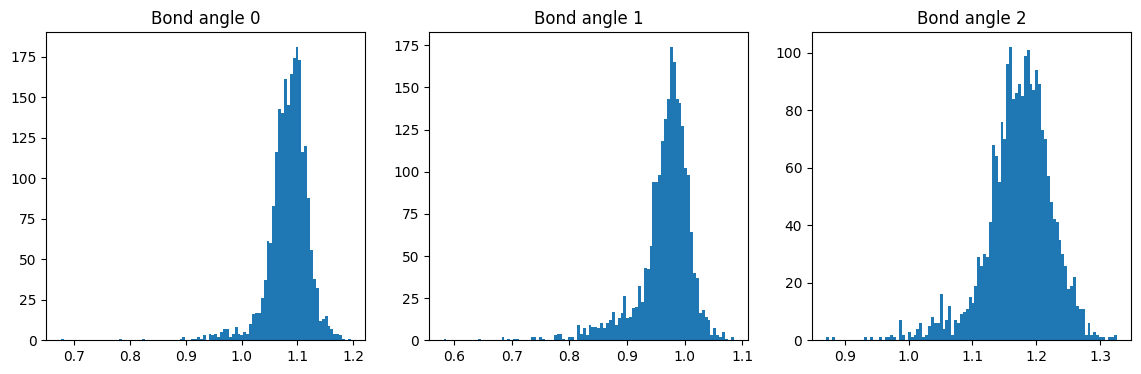

In [12]:
fig = plt.figure(figsize=(14, 4))
ax = plt.subplot(1, 3, 1)

ax.hist(bond_angles[:,0].reshape(-1), bins=100)
ax.set_title("Bond angle 0", fontsize=12)

ax = plt.subplot(1, 3, 2)
ax.hist(bond_angles[:,1].reshape(-1), bins=100)
ax.set_title("Bond angle 1", fontsize=12)

ax = plt.subplot(1, 3, 3)
ax.hist(bond_angles[:,2].reshape(-1), bins=100)
ax.set_title("Bond angle 2", fontsize=12)

Text(0.5, 1.0, 'Psi')

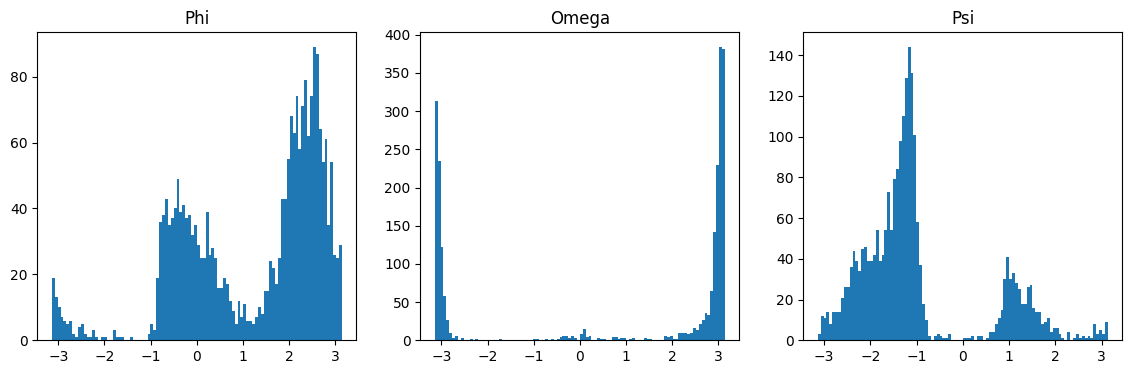

In [5]:
fig = plt.figure(figsize=(14, 4))
ax = plt.subplot(1, 3, 1)

ax.hist(dihedrals[:,0].reshape(-1), bins=100)
ax.set_title("Phi", fontsize=12)

ax = plt.subplot(1, 3, 2)
ax.hist(dihedrals[:,1].reshape(-1), bins=100)
ax.set_title("Omega", fontsize=12)

ax = plt.subplot(1, 3, 3)
ax.hist(dihedrals[:,2].reshape(-1), bins=100)
ax.set_title("Psi", fontsize=12)

It looks like we could get somewhere by symmetrising. i.e. encode the absolute value and the sign.

But not obvious whether this would actually save any 'space'.

In [ ]:
bin100 = BinEncoding.build(100, -np.pi, np.pi)
delta = DeltaEncoding()
phi_bins = bin100.encode(dihedrals[:,0])
phi_bins_delta = delta.encode(phi_bins)
ax = plt.subplot(1, 3, 1)
ax.hist(phi_bins_delta, bins=100)
ax.set_title("Phi", fontsize=12)

omega_bins = bin100.encode(dihedrals[:,1])
omega_bins_delta = delta.encode(omega_bins)
ax = plt.subplot(1, 3, 2)
ax.hist(omega_bins_delta, bins=100)
ax.set_title("Omega", fontsize=12)

psi_bins = bin100.encode(dihedrals[:,2])
psi_bins_delta = delta.encode(psi_bins)
ax = plt.subplot(1, 3, 3)
ax.hist(psi_bins_delta, bins=100)
ax.set_title("Psi", fontsize=12)


In [ ]:
import nerfax


def align_evaluate_rmsd(xyz, xyz_recons):
    # TODO: does this assume backbone only at all? Suppose not.
    xyz_reconstructed_aligned = nerfax.utils.get_align_rigid_bodies_fn(
        xyz_recons.reshape((-1,3)), xyz.reshape((-1,3))
    )(xyz_recons.reshape((-1,3)))
    return nerfax.foldcomp_tests.compute_rmsd(xyz_reconstructed_aligned, xyz.reshape((-1,3)))


xyz_reconstructed = nerfax.reconstruct.reconstruct_from_internal_coordinates(
    bond_lengths, bond_angles, dihedrals, mode="fully_sequential"  # i think this mode is cpu-optimised
)
print("Internal coords shape:", bond_lengths.shape, bond_angles.shape, dihedrals.shape)
print("RMSD:", align_evaluate_rmsd(xyz_bb, xyz_reconstructed))

In [ ]:
enc = HistogramEncoding.build(bond_lengths[:,0], 512)

In [ ]:
encoded = enc.encode(bond_lengths[:,0])
decoded = enc.decode(encoded)
decoded


For the dihedrals, we might want to bin encode then apply some optimal integer encoding - not huffman directly.

In [ ]:
# BACKBONE_BOND_LENGTHS[0]
decoded = {}
encoded = {}
for i in range(3):
    # bond_length_enc = SparseHistogramEncoding.build(bond_lengths[:,i], 512, zero_threshold=0.01, offset=BACKBONE_BOND_LENGTHS[i])
    bond_length_enc = HistogramEncoding.build(bond_lengths[:,i], 512)
    encoded[f"bond_length_{i}"] = bond_length_enc.encode(bond_lengths[:,i])
    decoded[f"bond_length_{i}"] = bond_length_enc.decode(encoded[f"bond_length_{i}"])

for i in range(3):
    bond_angle_enc = HistogramEncoding.build(bond_angles[:,i], 8192)
    encoded[f"bond_angle_{i}"] = bond_angle_enc.encode(bond_angles[:,i])
    decoded[f"bond_angle_{i}"] = bond_angle_enc.decode(encoded[f"bond_angle_{i}"])

print("Encoding phi")
phi_enc = HistogramEncoding.build(dihedrals[:,0], 16384, low=-np.pi, high=np.pi)
phi_encoded = phi_enc.encode(dihedrals[:,0])
encoded["phi"] = phi_encoded
decoded["phi"] = phi_enc.decode(phi_encoded)

print("Encoding omega")
omega_enc = HistogramEncoding.build(dihedrals[:,1], 16384, low=-np.pi, high=np.pi)
omega_encoded = omega_enc.encode(dihedrals[:,1])
encoded["omega"] = omega_encoded
decoded["omega"] = omega_enc.decode(omega_encoded)

print("Encoding psi")
psi_enc = HistogramEncoding.build(dihedrals[:,2], 16384, low=-np.pi, high=np.pi)
psi_encoded = psi_enc.encode(dihedrals[:,2])
encoded["psi"] = psi_encoded
decoded["psi"] = psi_enc.decode(psi_encoded)



In [ ]:
byte_sizes = {k: len(v) for k, v in encoded.items()}
byte_sizes, sum(byte_sizes.values()) / len(xyz_bb)

In [ ]:
def dict_to_internals(internals_dict):
    reconstructed_bond_lengths = np.stack([internals_dict["bond_length_0"], internals_dict["bond_length_1"], internals_dict["bond_length_2"]], axis=-1)
    reconstructed_bond_angles = np.stack([internals_dict["bond_angle_0"], internals_dict["bond_angle_1"], internals_dict["bond_angle_2"]], axis=-1)
    reconstructed_dihedrals = np.stack([internals_dict["phi"], internals_dict["omega"], internals_dict["psi"]], axis=-1)
    return reconstructed_bond_lengths, reconstructed_bond_angles, reconstructed_dihedrals


reconstructed_bond_lengths, reconstructed_bond_angles, reconstructed_dihedrals = dict_to_internals(decoded)

xyz_reconstructed = nerfax.reconstruct.reconstruct_from_internal_coordinates(
    reconstructed_bond_lengths, reconstructed_bond_angles, reconstructed_dihedrals, mode="fully_sequential"  # i think this mode is cpu-optimised
)
print("Internal coords shape:", bond_lengths.shape, bond_angles.shape, dihedrals.shape)
print("RMSD:", align_evaluate_rmsd(xyz_bb, xyz_reconstructed))